# Project Objective
##  Sales Performance & Profitability Analysis
* The objective of this project is to analyze sales, profit, and profitability trends across different categories, regions, and products using SQL, Python, and Power BI.
*  The project focuses on identifying growth patterns, regional performance, margin inefficiencies, and product-level profitability to support data-driven business decisions through interactive dashboard reporting. 

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

In [4]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


# Cleaning and Preparing Data

In [5]:
#removing extra spaces from column header
df.columns = df.columns.str.replace(' ','')

In [6]:
df

,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Country,City,...,PostalCode,Region,ProductID,Category,Sub-Category,ProductName,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RowID         9994 non-null   int64  
 1   OrderID       9994 non-null   object 
 2   OrderDate     9994 non-null   object 
 3   ShipDate      9994 non-null   object 
 4   ShipMode      9994 non-null   object 
 5   CustomerID    9994 non-null   object 
 6   CustomerName  9994 non-null   object 
 7   Segment       9994 non-null   object 
 8   Country       9994 non-null   object 
 9   City          9994 non-null   object 
 10  State         9994 non-null   object 
 11  PostalCode    9994 non-null   int64  
 12  Region        9994 non-null   object 
 13  ProductID     9994 non-null   object 
 14  Category      9994 non-null   object 
 15  Sub-Category  9994 non-null   object 
 16  ProductName   9994 non-null   object 
 17  Sales         9994 non-null   float64
 18  Quantity      9994 non-null 

In [8]:
df.isnull().sum()

RowID           0
OrderID         0
OrderDate       0
ShipDate        0
ShipMode        0
CustomerID      0
CustomerName    0
Segment         0
Country         0
City            0
State           0
PostalCode      0
Region          0
ProductID       0
Category        0
Sub-Category    0
ProductName     0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [9]:
df.shape

(9994, 21)

In [10]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["ShipDate"] = pd.to_datetime(df["ShipDate"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   RowID         9994 non-null   int64         
 1   OrderID       9994 non-null   object        
 2   OrderDate     9994 non-null   datetime64[ns]
 3   ShipDate      9994 non-null   datetime64[ns]
 4   ShipMode      9994 non-null   object        
 5   CustomerID    9994 non-null   object        
 6   CustomerName  9994 non-null   object        
 7   Segment       9994 non-null   object        
 8   Country       9994 non-null   object        
 9   City          9994 non-null   object        
 10  State         9994 non-null   object        
 11  PostalCode    9994 non-null   int64         
 12  Region        9994 non-null   object        
 13  ProductID     9994 non-null   object        
 14  Category      9994 non-null   object        
 15  Sub-Category  9994 non-null   object  

In [12]:
df

,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Country,City,...,PostalCode,Region,ProductID,Category,Sub-Category,ProductName,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [13]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   RowID         9994 non-null   int64         
 1   OrderID       9994 non-null   object        
 2   OrderDate     9994 non-null   datetime64[ns]
 3   ShipDate      9994 non-null   datetime64[ns]
 4   ShipMode      9994 non-null   object        
 5   CustomerID    9994 non-null   object        
 6   CustomerName  9994 non-null   object        
 7   Segment       9994 non-null   object        
 8   Country       9994 non-null   object        
 9   City          9994 non-null   object        
 10  State         9994 non-null   object        
 11  PostalCode    9994 non-null   int64         
 12  Region        9994 non-null   object        
 13  ProductID     9994 non-null   object        
 14  Category      9994 non-null   object        
 15  Sub-Category  9994 non-null   object  

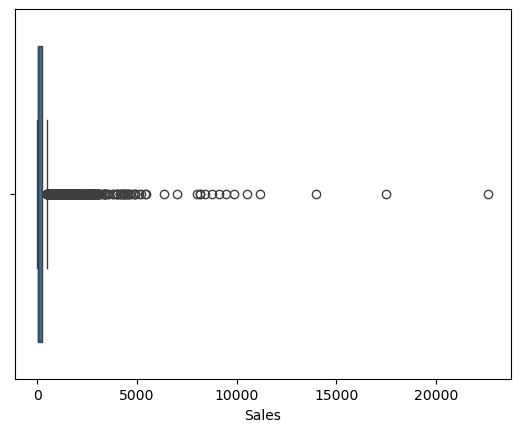

In [15]:
#Checking outliers
sns.boxplot(x=df['Sales'])
plt.show()

## Highly right-skewed distribution
* Most data is clustered near low sales values
* Few points go very far right (up to ~20K+)
### Insights -: Majority of orders are small value, but a few large orders drive revenue.

## Many outliers (but they are valid)
* All those dots on the right = high-value orders
* These are not errors → they are important business transactions

## Median is very low
* The box is squeezed near 0
* Indicates:Typical order value is low
  
### Sales distribution is highly right-skewed, with most transactions having low values and a small number of high-value orders acting as outliers. These outliers represent bulk or enterprise purchases and contribute significantly to total revenue.

### Outliers do not need to be removed as they are core to business understanding

## Key Insight - Revenue is concentrated in a small number of high-value transactions, indicating dependency on large orders.

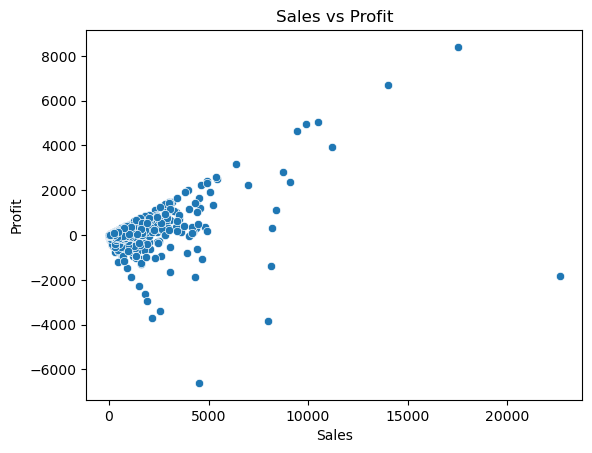

In [16]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

## Weak relationship between Sales and Profit
* Some high sales → high profit
* Some high sales → negative profit
* Insight:Sales and profit are not strongly correlated.

## High variability at higher sales
* As sales increase, profit spreads widely
* You see both:
High profit
Heavy losses
* Insight:Higher sales come with higher risk of loss, indicating inconsistent margins.

## Presence of loss-making high-value orders
Points with:
* Sales > 5000 --- Profit < 0
* Insight: Some large transactions are actually unprofitable.

## The scatter plot shows that higher sales do not guarantee higher profit. While some high-value transactions generate strong profit, others result in significant losses, indicating weak correlation between sales and profitability. This suggests inconsistent pricing or discounting strategies, where certain high-revenue orders negatively impact overall profit.


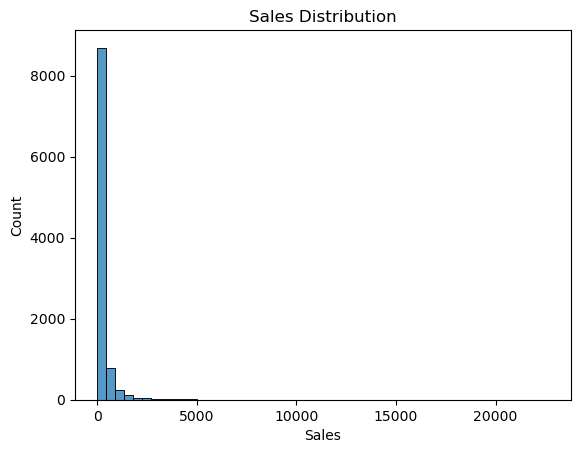

In [17]:
# Sales distribution
sns.histplot(df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

* Sales are highly right-skewed
* Most orders are low value
* Few large orders drive major revenue
### Conclusion:Business depends on a small number of high-value transactions, but typical order size is low.

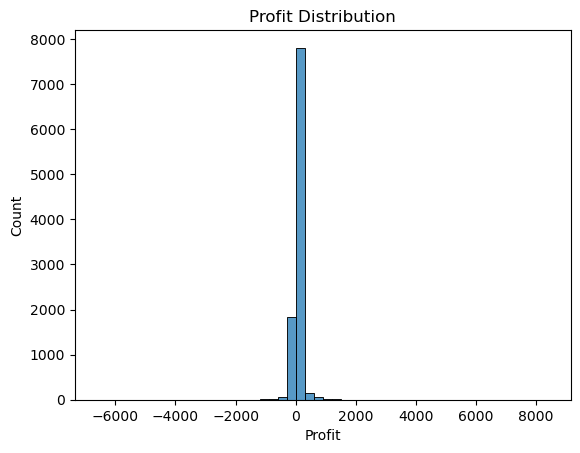

In [18]:
# Profit distribution
sns.histplot(df['Profit'], bins=50)
plt.title("Profit Distribution")
plt.show()

* Profit is centered around 0
* Many orders have low or negative profit
* High variability in margins
### Conclusion:Profitability is inconsistent, with several transactions generating little or no profit.


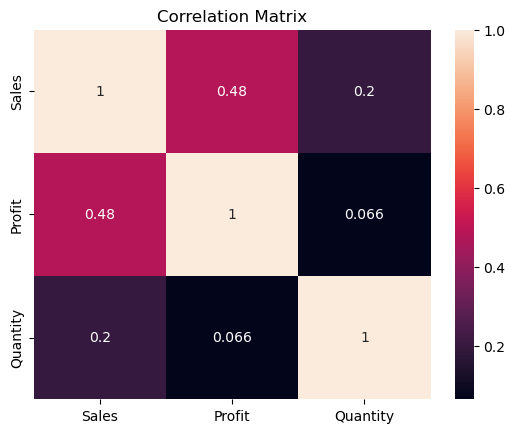

In [19]:
#Correlation
sns.heatmap(df[['Sales','Profit','Quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Correlation Matrix Analysis

### Variables: Sales, Profit, Quantity

| | Sales | Profit | Quantity |
|-----------|-------|--------|----------|
| **Sales** | 1.00 | 0.48 | 0.20 |
| **Profit** | 0.48 | 1.00 | 0.066 |
| **Quantity** | 0.20 | 0.066 | 1.00 |

### Key Insights

- **Sales vs Profit (0.48):** Moderate positive correlation — higher sales tend to associate with higher profit, but not strongly.
- **Sales vs Quantity (0.20):** Weak positive correlation — quantity sold has limited direct impact on sales value.
- **Profit vs Quantity (0.066):** Very weak correlation — quantity sold barely relates to profit, suggesting margin variation across products.

### Interpretation Scale
| Range | Strength |
|-------|----------|
| 0.8 – 1.0 | Strong |
| 0.5 – 0.8 | Moderate |
| 0.2 – 0.5 | Weak |
| 0.0 – 0.2 | Very Weak |

> **Note:** All correlations are positive. No strong multicollinearity detected among the three variables.

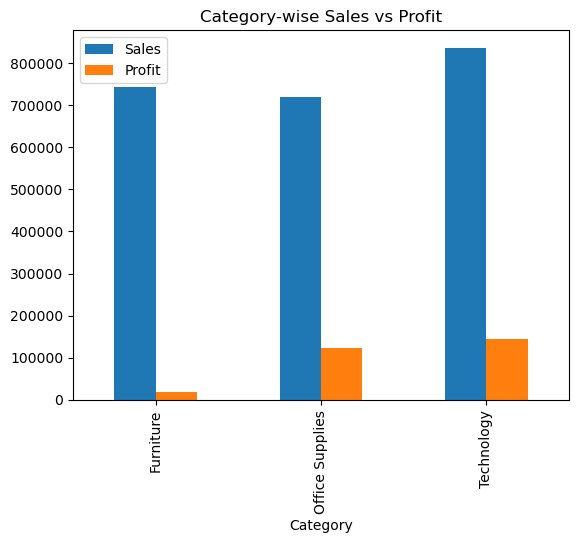

In [20]:
# Category-wise Analysis
df.groupby('Category')[['Sales','Profit']].sum().plot(kind='bar')
plt.title("Category-wise Sales vs Profit")
plt.show()

## Category-wise Sales vs Profit Analysis

### Approximate Values

| Category | Sales | Profit | Profit Margin |
|----------------|----------|---------|---------------|
| **Furniture** | ~750,000 | ~18,000 | ~2.4% |
| **Office Supplies** | ~720,000 | ~125,000 | ~17.4% |
| **Technology** | ~835,000 | ~145,000 | ~17.4% |

### Key Insights

- **Technology** leads in both **Sales (~835K)** and **Profit (~145K)** — the most commercially effective category.
- **Office Supplies** has similar sales to Furniture (~720K) but yields a **significantly higher profit (~125K)**, indicating better margins.
- **Furniture** is the most concerning category — despite high sales (~750K), profit is extremely low (~18K), suggesting:
  - High cost of goods or operations
  - Heavy discounting
  - Potential loss-making sub-categories

### Profit Margin Comparison

| Category | Margin |
|----------------|--------|
| Furniture | 🔴 ~2.4% (Very Low) |
| Office Supplies | 🟢 ~17.4% (Healthy) |
| Technology | 🟢 ~17.4% (Healthy) |

> **Recommendation:** Investigate Furniture's cost structure — it contributes significant revenue but
> barely any profit. Consider renegotiating supplier costs or discontinuing low-margin sub-categories.

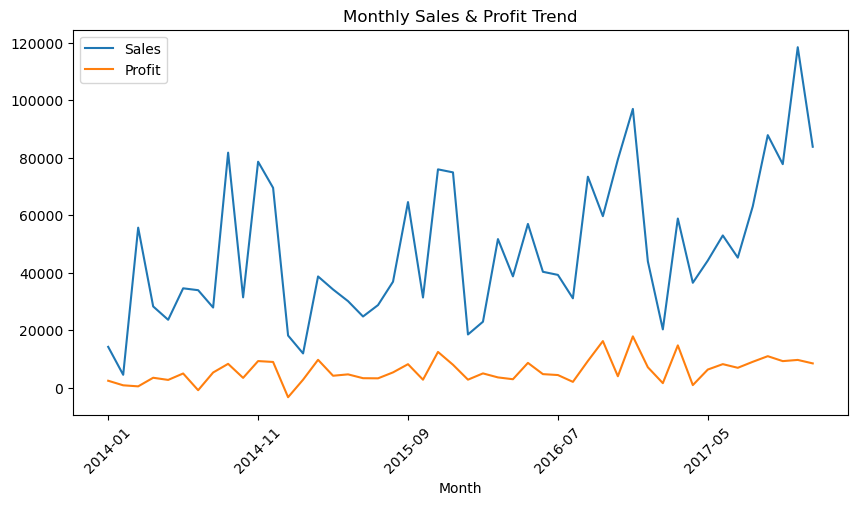

In [21]:
#Monthly Trend Visual
df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)

monthly = df.groupby('Month')[['Sales','Profit']].sum()

monthly.plot(figsize=(10,5))
plt.xticks(rotation=45)
plt.title("Monthly Sales & Profit Trend")
plt.show()

## Sales & Profit Trend (2014–2017)

- **Sales have grown a lot** — from around $8K in early 2014 to $119K by late 2017
- **Profits haven't kept up** — they stayed mostly flat between $0–$15K the whole time
- **Every year follows the same pattern** — sales are slow at the start of the year
  and spike towards the end (likely holiday/year-end buying)
- **We're selling more but earning less per sale** — in 2017, $119K in sales only made ~$10K in profit
- **Once in late 2014, the business actually lost money** — profit went below zero

### Bottom Line
> The business is growing in size but **not in profitability**.
> Either costs are going up, or too many discounts are being given away.


# Create SQLite DB

In [22]:
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

9994

In [23]:
##verifying
# pd.read_sql("SELECT COUNT(*) FROM sales", conn)

# Start SQL (core part)

In [24]:
query = """select * from sales
        """
pd.read_sql(query,conn)

,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Country,City,...,Region,ProductID,Category,Sub-Category,ProductName,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21 00:00:00,2014-01-23 00:00:00,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014-01
9990,9991,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017-02
9991,9992,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017-02
9992,9993,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017-02


In [25]:
# Sales by Region
query = """select region, sum(sales) as TotalSales from sales
        group by region"""
pd.read_sql(query,conn)

,Region,TotalSales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [26]:
# Top Customers

query = """
           select CustomerName, sum(sales) as TotalSales from Sales
           group by CustomerName
           order by TotalSales desc
           limit 10
        """
pd.read_sql(query,conn)

,CustomerName,TotalSales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


In [27]:
# Monthly Sales
query = """
        select strftime('%Y-%m',OrderDate) as Month, round(sum(sales),2) as MonthlySales, round(sum(profit),2) as MonthlyProfit from sales
        Group by Month
        order by Month desc
        """
pd.read_sql(query,conn)
        


,Month,MonthlySales,MonthlyProfit
0,2017-12,83829.32,8483.35
1,2017-11,118447.82,9690.10
2,2017-10,77776.92,9275.28
3,2017-09,87866.65,10991.56
4,2017-08,63120.89,9040.96
5,2017-07,45264.42,6952.62
6,2017-06,52981.73,8223.34
7,2017-05,44261.11,6342.58
8,2017-04,36521.54,933.29
9,2017-03,58872.35,14751.89


## Overall Growth Trend
* 2014 → lower sales
* 2015–2016 → steady growth
* 2017 → highest performance (peak ~118K)
* Insight:Sales show a clear upward trend over time, indicating business growth, with 2017 being the strongest year.

## Strong Seasonality (very important)
* Pattern repeats every year:
* Sep–Dec → peak months
* Nov & Dec → highest sales
Examples:
* 2014-09 → 81K
* 2015-11 → 75K
* 2016-12 → 96K
* 2017-11 → 118K
* Insight:There is strong seasonality with consistent spikes in Q4, likely driven by year-end demand or festive periods.

## Profit ≠ Sales (critical finding)
Examples:
* 2014-07 → sales 33K, profit -841
* 2015-01 → sales 18K, profit -3281
* 2016-11 → sales 79K, profit only 4K
* Insight:High sales do not always translate into profit, indicating margin issues due to discounting or high costs.

## Loss-making periods
* 2014-07 → negative profit
* 2015-01 → major loss
* Insight:Certain months incur losses despite revenue, suggesting poor pricing or operational inefficiencies during those periods.

## Profit improvement over time
* Early years → inconsistent profit
* Later years (2016–2017) → stronger and more stable profit
Example:
* 2016-12 → ~17.8K profit
* 2017 months → mostly positive and stable
* Insight:Profitability improves over time, indicating better margin management or cost control strategies.

## Peak performance period
* Nov 2017 → highest sales (~118K)
* Strong profits in late 2016 and 2017
* Insight:The business reaches peak performance in late 2017, both in terms of revenue and profitability.

## The analysis reveals a clear upward sales trend with strong seasonal spikes in Q4 each year. However, profitability does not consistently align with revenue, as some high-sales months result in low or negative profit, indicating margin inefficiencies. Over time, profitability stabilizes and improves, suggesting better pricing or cost control strategies in later years.


In [28]:
# Category wise sales
query = """
           select category, sum(sales) as TotalSales, sum(profit) as TotalProfit from sales
           group by category
           order by sum(profit) desc
           
        """

pd.read_sql(query,conn)


,Category,TotalSales,TotalProfit
0,Technology,836154.0330,145454.9481
1,Office Supplies,719047.0320,122490.8008
2,Furniture,741999.7953,18451.2728


## Technology = best performing
Sales: ~836K
Profit: ~145K
→ High revenue and strong profit
→ Healthy margins

## Furniture = biggest problem
Sales: ~742K (almost as high as Technology)
Profit: ~18K (very low)
→ Huge red flag

## Office Supplies = efficient
Sales: ~719K
Profit: ~122K
→ Lower sales than Furniture but much higher profit
## Furniture category generates high revenue but very low profit, indicating poor margins. This aligns with earlier findings where multiple loss-making products belong to the Tables sub-category, suggesting structural pricing or cost issues.
##

In [29]:
df.columns

Index(['RowID', 'OrderID', 'OrderDate', 'ShipDate', 'ShipMode', 'CustomerID',
       'CustomerName', 'Segment', 'Country', 'City', 'State', 'PostalCode',
       'Region', 'ProductID', 'Category', 'Sub-Category', 'ProductName',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Month'],
      dtype='object')

In [30]:
# Top loss-making products
query = """
        select ProductName, Category, [Sub-Category],
        Round(sum(sales),2) as TotalSales,
        Round(sum(Profit),2) as TotalProfit,
        Count(*) as OrderCount
        from sales
        group by ProductName, Category, [Sub-Category]
        having sum(Profit) < 0
        order by TotalProfit asc
        limit 10

        """
pd.read_sql(query,conn)
        


,ProductName,Category,Sub-Category,TotalSales,TotalProfit,OrderCount
0,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.96,-8879.97,3
1,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.90,-4589.97,4
2,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.98,-3839.99,1
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.64,-2876.12,5
4,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.73,-1934.40,7
5,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.07,-1878.17,6
6,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.48,-1811.08,1
7,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.20,-1299.18,6
8,Balt Solid Wood Round Tables,Furniture,Tables,6518.75,-1201.06,4
9,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.25,-1148.44,3


## Machines category is the biggest problem
Multiple entries (3D printers, Lexmark, Cisco)
Very high sales + very high losses
Example:
Cubify CubeX → ~11K sales, -8.8K loss
* Insight:High-ticket tech products are heavily loss-making → likely due to high cost or aggressive discounting.

## Furniture (Tables) is consistently unprofitable
Many entries in Tables
Moderate to high sales but repeated losses
* Insight:Tables category has systemic margin issues, not just one bad product.

## High revenue ≠ profitability
Examples:
GBC DocuBind → ~17.9K sales, -1.8K loss
Cisco system → ~22.6K sales, -1.8K loss
* Insight:Some of the highest revenue products are destroying profit.

## Order count is low but impact is high
Some products: 1–3 orders only
Still huge losses
* Insight: Even low-frequency sales can significantly impact profit if margins are negative.

## *Analysis identified that high-value products in the Technology (Machines) category and Furniture (Tables) category are consistently loss-making despite strong sales. This indicates pricing or cost inefficiencies, where high revenue does not translate into profitability. Some products generate significant losses even with low order frequency, suggesting margin issues rather than volume problems.*

In [31]:
# Highest Profit for each category region wise
query = """
           select region,category, sum(sales) as totalsales, round(sum(Profit),2) as TotalProfit
           from sales
           group by region, category
           order by sum(profit) desc
        """
pd.read_sql(query,conn)
           

,Region,Category,totalsales,TotalProfit
0,West,Office Supplies,220853.2490,52609.85
1,East,Technology,264973.9810,47462.04
2,West,Technology,251991.8320,44303.65
3,East,Office Supplies,205516.0550,41014.58
4,Central,Technology,170416.3120,33697.43
5,South,Technology,148771.9080,19991.83
6,South,Office Supplies,125651.3130,19986.39
7,West,Furniture,252612.7435,11504.95
8,Central,Office Supplies,167026.4150,8879.98
9,South,Furniture,117298.6840,6771.21


## Office Supplies in West = highest profit driver
Profit ≈ 52K
→ Best performing combo
## Technology performs consistently across regions
East, West, Central, South → all profitable
→ Stable category
## Furniture is the weakest across regions
Very low profit everywhere
Central = negative profit (-2.8K)
→ Confirms your earlier finding

## Key insight -: Furniture category underperforms across all regions and even generates losses in the Central region, indicating systemic margin issues rather than a region-specific problem.
##

In [32]:
# Highest profit region wise

query = """
            select region, sum(profit) as TotalProfit, sum(Sales) as TotalSales from sales
            group by region
            order by sum(profit) desc
  
       """
pd.read_sql(query,conn)

,Region,TotalProfit,TotalSales
0,West,108418.4489,725457.8245
1,East,91522.7800,678781.2400
2,South,46749.4303,391721.9050
3,Central,39706.3625,501239.8908


## West is the strongest region
Highest profit AND highest sales
→ Healthy business performance

## Central region is inefficient
Sales (~501K) > South (~391K)
But profit (~39K) < South (~46K)
* Insight: Central region generates decent revenue but converts poorly into profit → margin problem

## South is more efficient than Central
Lower sales but higher profit
* Insight: Better pricing or lower costs in South region
  
## The West region performs best with the highest sales and profit, indicating strong demand and healthy margins. However, the Central region shows inefficiency, where relatively high sales do not translate into proportional profit, suggesting margin or cost issues. In contrast, the South region, despite lower sales, delivers better profitability, indicating stronger margin management.

# Summary
### Category-level issue → Furniture weak
### Product-level issue → Tables causing losses
### Region + category level → Furniture failing everywhere
## Analysis shows that while Office Supplies and Technology drive profitability across regions, the Furniture category consistently underperforms and even results in losses in certain regions like Central. This aligns with product-level findings where multiple table products were identified as loss-making, indicating a broader margin issue within the category.

In [33]:
#Considering only required columns for data analysis
df = df[['OrderDate','Sales','Profit','Quantity',
     'Category','Sub-Category','Region','ProductName']]

In [34]:
df

,OrderDate,Sales,Profit,Quantity,Category,Sub-Category,Region,ProductName
0,2016-11-08,261.9600,41.9136,2,Furniture,Bookcases,South,Bush Somerset Collection Bookcase
1,2016-11-08,731.9400,219.5820,3,Furniture,Chairs,South,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,2016-06-12,14.6200,6.8714,2,Office Supplies,Labels,West,Self-Adhesive Address Labels for Typewriters b...
3,2015-10-11,957.5775,-383.0310,5,Furniture,Tables,South,Bretford CR4500 Series Slim Rectangular Table
4,2015-10-11,22.3680,2.5164,2,Office Supplies,Storage,South,Eldon Fold 'N Roll Cart System
...,...,...,...,...,...,...,...,...
9989,2014-01-21,25.2480,4.1028,3,Furniture,Furnishings,South,Ultra Door Pull Handle
9990,2017-02-26,91.9600,15.6332,2,Furniture,Furnishings,West,Tenex B1-RE Series Chair Mats for Low Pile Car...
9991,2017-02-26,258.5760,19.3932,2,Technology,Phones,West,Aastra 57i VoIP phone
9992,2017-02-26,29.6000,13.3200,4,Office Supplies,Paper,West,"It's Hot Message Books with Stickers, 2 3/4"" x 5"""


In [35]:
#exporting the file
df.to_csv("cleaned_sales_data.csv", index=False)

# Conclusion
## 5 Key Findings
* Sales showed consistent year-over-year growth with strong seasonal spikes during Q4 across all years.
* Technology emerged as the most profitable category with strong sales and healthy profit margins, while Furniture generated high sales but weak profitability.
* The West region contributed the highest overall profit, whereas the Central region underperformed despite moderate sales.
* Product-level analysis revealed that higher sales do not always translate into higher profitability, indicating pricing or margin inefficiencies in certain products.
* Profit margin analysis highlighted that business performance should be evaluated beyond revenue alone, as profitability varied significantly across categories and products.